In [6]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

from xgboost import XGBRegressor


Load Feature engineered dataset

In [8]:
df = pd.read_csv('../data/processed/feature_engineering_data.csv')

df.head()

,Date,Year,Month,Price_alum,Price_gold,Price_nickel,Price_silver,Price_uran,Inflation_rate,Price_alum_infl,Price_gold_infl,Price_nickel_infl,Price_silver_infl,Price_uran_infl,Month_Num,Quarter,Price_gold_Lag_1,Price_gold_Lag_2,Price_gold_Lag_3,Price_gold_Rolling_Mean_3,Price_gold_Returns,Price_silver_Lag_1,Price_silver_Lag_2,Price_silver_Lag_3,Price_silver_Rolling_Mean_3,Price_silver_Returns,Price_alum_Lag_1,Price_alum_Lag_2,Price_alum_Lag_3,Price_alum_Rolling_Mean_3,Price_alum_Returns,Price_nickel_Lag_1,Price_nickel_Lag_2,Price_nickel_Lag_3,Price_nickel_Rolling_Mean_3,Price_nickel_Returns,Price_uran_Lag_1,Price_uran_Lag_2,Price_uran_Lag_3,Price_uran_Rolling_Mean_3,Price_uran_Returns
0,1992-05-01,1992,May,1306.79,337.24,7326.8,4.07,7.55,89.59,2477.543161,639.373316,13890.88012,7.716313,14.314045,5,2,338.62,344.34,353.91,340.066667,-0.004075,4.05,4.11,4.15,4.076667,0.004938,1317.05,1280.47,1266.83,1301.436667,-0.007790,7420.6,7417.7,7861.9,7388.366667,-0.012640,7.75,7.75,7.90,7.683333,-0.025806
1,1992-06-01,1992,Jun,1275.55,340.81,7192.8,4.06,7.75,89.59,2418.315245,646.141679,13636.82952,7.697354,14.693225,6,2,337.24,338.62,344.34,338.890000,0.010586,4.07,4.05,4.11,4.060000,-0.002457,1306.79,1317.05,1280.47,1299.796667,-0.023906,7326.8,7420.6,7417.7,7313.400000,-0.018289,7.55,7.75,7.75,7.683333,0.026490
2,1992-07-01,1992,Jul,1313.05,352.72,7497.9,3.97,7.75,89.59,2489.411495,668.721848,14215.26861,7.526723,14.693225,7,3,340.81,337.24,338.62,343.590000,0.034946,4.06,4.07,4.05,4.033333,-0.022167,1275.55,1306.79,1317.05,1298.463333,0.029399,7192.8,7326.8,7420.6,7339.166667,0.042417,7.75,7.55,7.75,7.683333,0.000000
3,1992-08-01,1992,Aug,1305.05,343.06,7268.0,3.81,8.05,89.59,2474.244295,650.407454,13779.40120,7.223379,15.261995,8,3,352.72,340.81,337.24,345.530000,-0.027387,3.97,4.06,4.07,3.946667,-0.040302,1313.05,1275.55,1306.79,1297.883333,-0.006093,7497.9,7192.8,7326.8,7319.566667,-0.030662,7.75,7.75,7.55,7.850000,0.038710
4,1992-09-01,1992,Sep,1269.61,345.43,6917.5,3.77,8.75,89.59,2407.053599,654.900737,13114.88825,7.147543,16.589125,9,3,343.06,352.72,340.81,347.070000,0.006908,3.81,3.97,4.06,3.850000,-0.010499,1305.05,1313.05,1275.55,1295.903333,-0.027156,7268.0,7497.9,7192.8,7227.800000,-0.048225,8.05,7.75,7.75,8.183333,0.086957


Define metals

In [9]:
metals = [ "Price_gold", "Price_silver", "Price_alum", "Price_uran", "Price_nickel"]

In [10]:
xgb_results = []

Train xgboost for each metal

Results for Price_gold
MAE:  70.24990770128039
RMSE:  102.44582148397834
R^2 Score:  0.8315825849217742


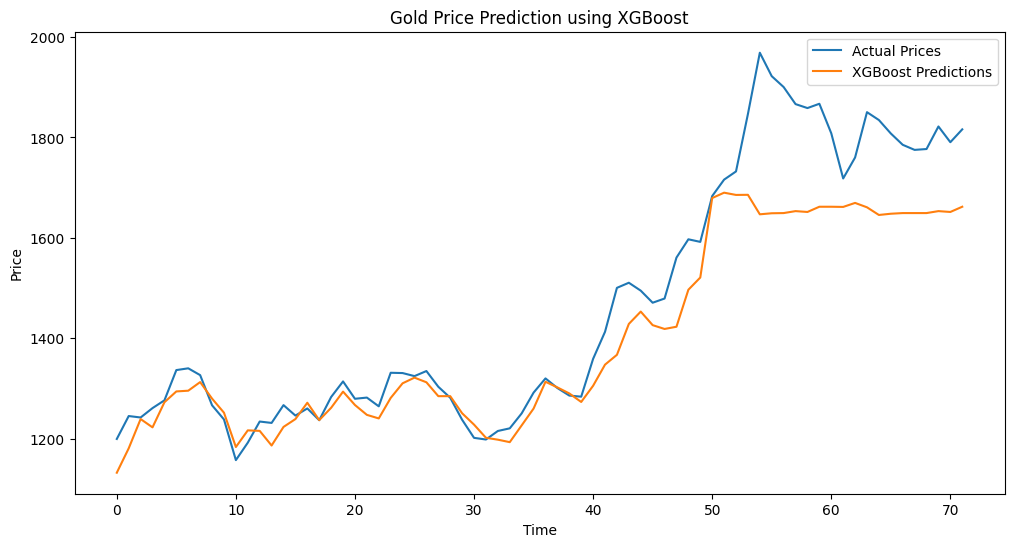

Results for Price_silver
MAE:  0.8693955320782129
RMSE:  1.3662314913222988
R^2 Score:  0.8775583573679411


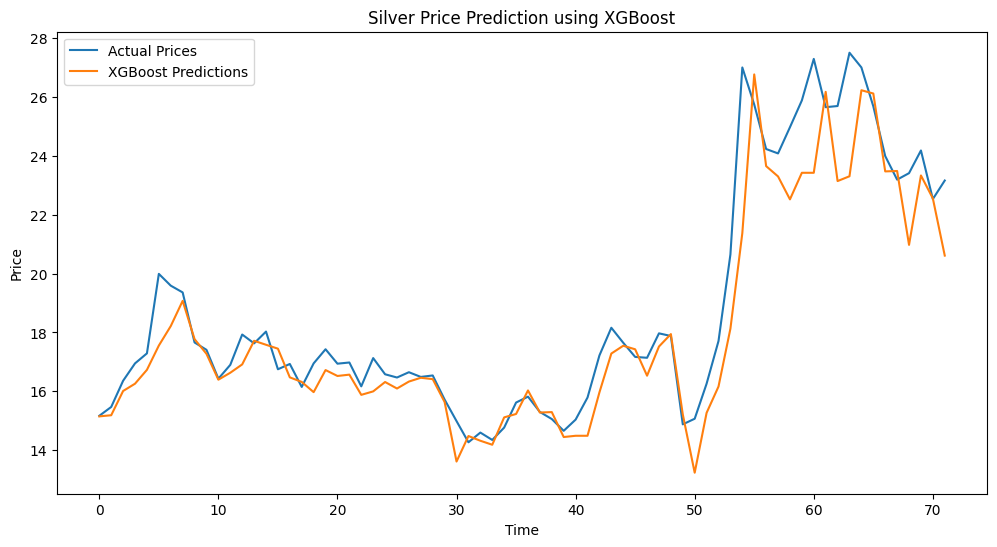

Results for Price_alum
MAE:  43.442833251953125
RMSE:  66.77589783112275
R^2 Score:  0.962508742834552


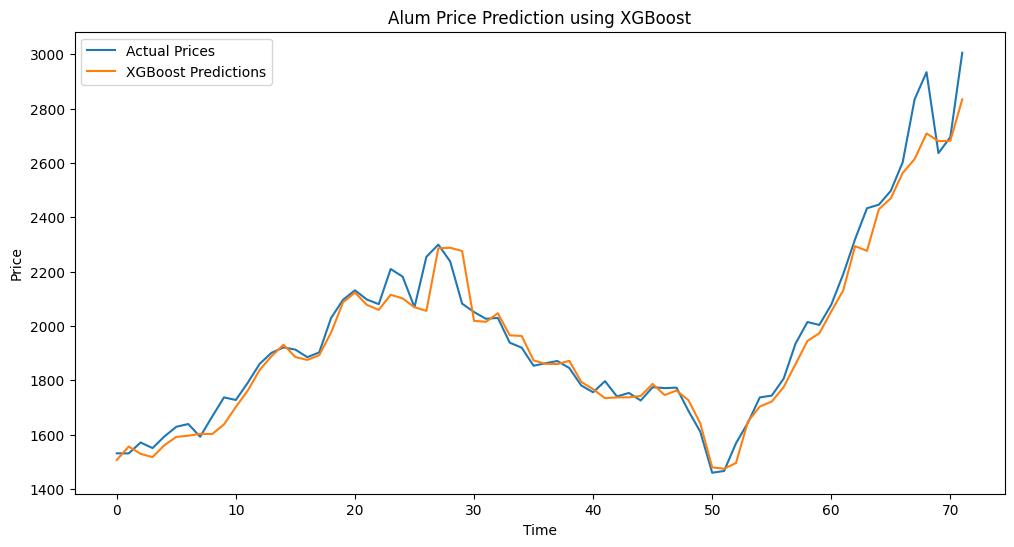

Results for Price_uran
MAE:  2.490974538591173
RMSE:  3.3209424384388706
R^2 Score:  0.49295748054683386


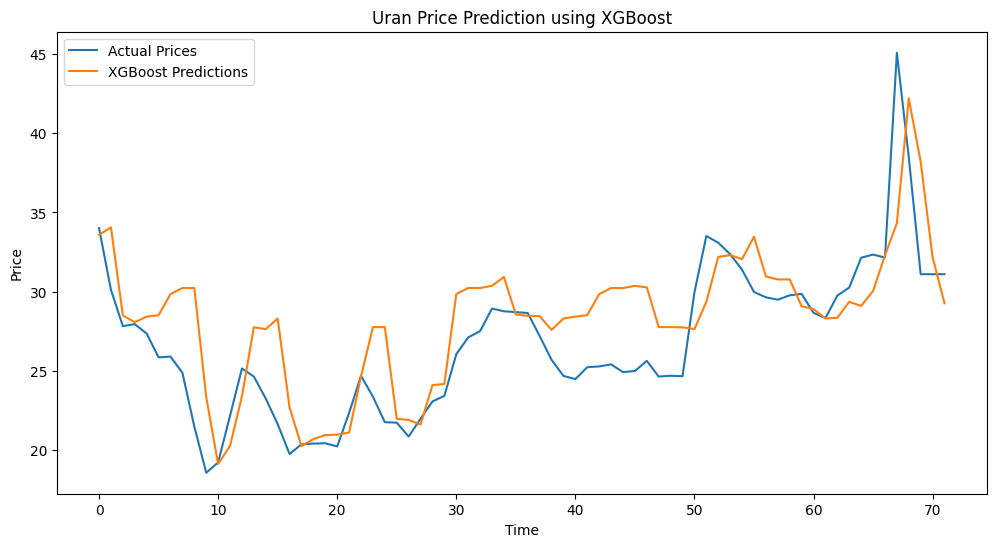

Results for Price_nickel
MAE:  627.0908482530381
RMSE:  780.0740111134419
R^2 Score:  0.9439820793390181


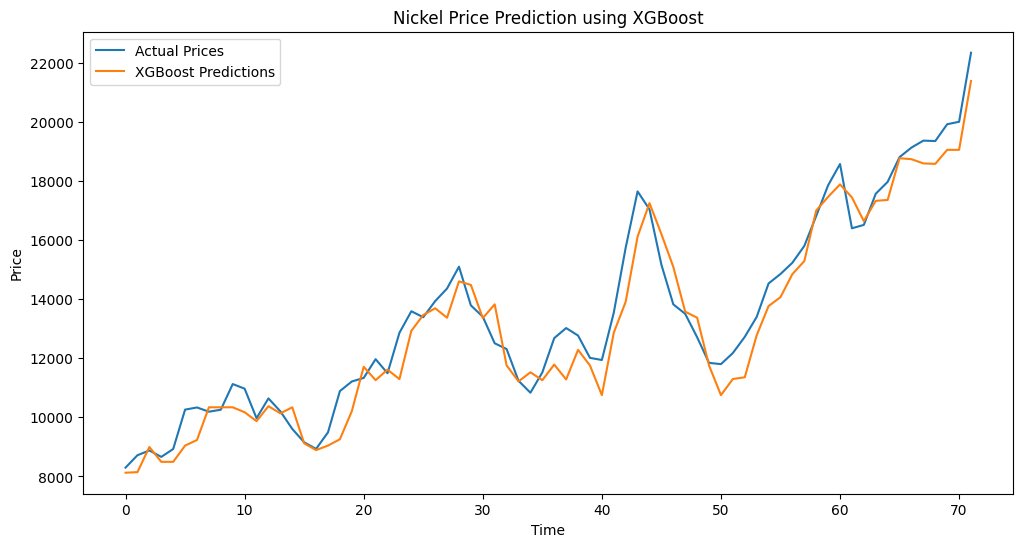

In [19]:
for metal in metals:
    print(f"Results for {metal}")

    X = df[
        [
            "Year",
            "Month_Num",
            "Quarter",

            f"{metal}_Lag_1",
            f"{metal}_Lag_2",
            f"{metal}_Lag_3",

            f"{metal}_Rolling_Mean_3",
        ]
    ]

    y = df[metal]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    xgb_model = XGBRegressor( n_estimators = 100, learning_rate = 0.1, max_depth = 5, random_state = 42)

    xgb_model.fit(X_train, y_train)

    predictions = xgb_model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error( y_test, predictions))
    r2score = r2_score(y_test, predictions)

    print("MAE: ", mae)
    print("RMSE: ", rmse)
    print("R^2 Score: ", r2score)

    xgb_results.append({"Metal": metal, "MAE": mae, "RMSE": rmse, "R^2 Score": r2score})

    clean_name = metal.replace( "Price_", "" ).capitalize()

    plt.figure(figsize=(12,6))

    plt.plot( y_test.values, label="Actual Prices")

    plt.plot(predictions, label="XGBoost Predictions")

    plt.title( f"{clean_name} Price Prediction using XGBoost")

    plt.xlabel("Time")

    plt.ylabel("Price")

    plt.legend()

    plt.show()

In [17]:
xgb_results_df = pd.DataFrame(xgb_results)
xgb_results_df

,Metal,MAE,RMSE,R^2 Score
0,Price_gold,70.249908,102.445821,0.831583
1,Price_silver,0.869396,1.366231,0.877558
2,Price_alum,43.442833,66.775898,0.962509
3,Price_uran,2.490975,3.320942,0.492957
4,Price_nickel,627.090848,780.074011,0.943982


Feature Importance

In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                       Feature  Importance
6  Price_nickel_Rolling_Mean_3    0.936898
3           Price_nickel_Lag_1    0.043269
0                         Year    0.006797
1                    Month_Num    0.004888
4           Price_nickel_Lag_2    0.004432
5           Price_nickel_Lag_3    0.003715
2                      Quarter    0.000000


Visualization

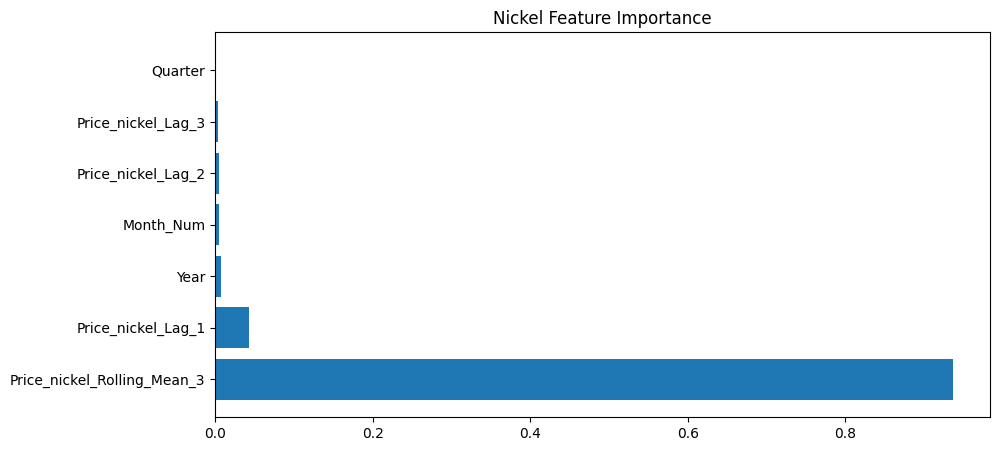

In [21]:
plt.figure(figsize=(10,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    f"{clean_name} Feature Importance"
)

plt.show()